# Game development basics with pygame
* welcome to the game development part of this course! we start from absolute basics here and, across the next several lessons, build all the way up to a small but complete RPG (role playing game)
* **pygame** is by far the most popular python library for building 2D games - it wraps a lower-level library called SDL (used by tons of real, professional games and game engines) and gives us python-friendly building blocks: windows, drawing, images, sound, input, timing, ...
* `pip install pygame` is all you need - no other dependency

## a very important note about THIS notebook environment
* pygame normally opens a real window on your screen and you interact with it live (keyboard/mouse) - that's simply not possible inside a headless notebook environment running on a server with no screen attached
* SDL (the library pygame wraps) has a neat trick for exactly this situation: an **off-screen "dummy" video driver**. instead of opening a real window, it renders everything into memory only - which is perfect for testing, for automated scripts, for CI pipelines, and (very conveniently for us) for a jupyter notebook that needs to just SHOW you a picture of the result
* we activate it by setting two environment variables BEFORE we import pygame at all: `SDL_VIDEODRIVER=dummy` (no real window) and `SDL_AUDIODRIVER=dummy` (no real sound device)
* **on your own computer, for a real game, you would simply NOT set these two variables** - pygame then automatically opens a real window and plays real sound, no code changes needed anywhere else. we only need this workaround because THIS specific notebook runs on a server with no display attached
* to actually SEE what we drew, we convert the pygame surface into a numpy array (recap lesson 19!) and display it with matplotlib's `imshow` (recap lesson 20) - on your own machine you would instead just see the real, live window pygame opened for you

pygame 2.6.1 (SDL 2.28.4, Python 3.11.15)
Hello from the pygame community. https://www.pygame.org/contribute.html


pygame initialized, version: 2.6.1


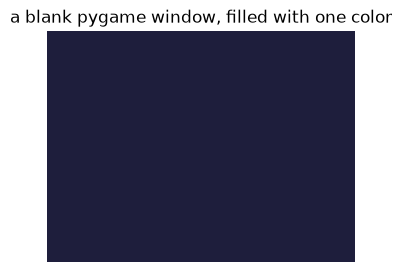

In [1]:
import os

# these two lines MUST run before "import pygame" - pygame reads them once, right when SDL starts up
os.environ["SDL_VIDEODRIVER"] = "dummy"  # render off-screen instead of opening a real window
os.environ["SDL_AUDIODRIVER"] = "dummy"  # use a fake, silent audio device instead of a real sound card

import pygame
import numpy as np
import matplotlib.pyplot as plt

pygame.init()  # starts up every pygame subsystem (video, mostly what we need)
print("pygame initialized, version:", pygame.version.ver)


def show_surface(surface, title=None, figsize=(4, 3)):
    """Our little helper for this whole game-dev part of the course: render a pygame Surface inline in the notebook."""
    # pygame stores pixel arrays as (width, height, channels) - matplotlib expects (height, width, channels), so we swap the first two axes
    pixel_array = pygame.surfarray.array3d(surface).swapaxes(0, 1)
    plt.figure(figsize=figsize)
    plt.imshow(pixel_array)
    plt.axis("off")  # a game screenshot doesnt need x/y axis ticks and labels
    if title:
        plt.title(title)
    plt.show()


# lets immediately try it: a blank window-sized surface, filled with one color
screen = pygame.display.set_mode((320, 240))  # creates our "window" (off-screen, thanks to the dummy driver)
screen.fill((30, 30, 60))  # fill the whole thing with a dark blue - pygame colors are (red, green, blue), 0-255 each
show_surface(screen, title="a blank pygame window, filled with one color")

## drawing primitives
* pygame's `pygame.draw` module can draw rectangles, circles, lines, polygons and more directly onto a surface
* remember: the coordinate system has `(0, 0)` at the TOP-LEFT corner, and y grows DOWNWARDS - this trips up almost everyone coming from math class (where y usually grows upward), so keep it in mind

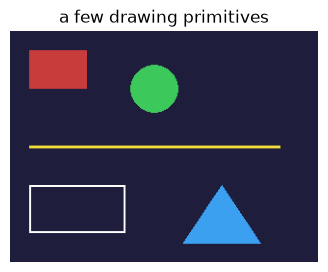

In [2]:
screen.fill((30, 30, 60))  # clear the screen back to our background color first

# pygame.draw.rect(surface, color, rect) - rect is (x, y, width, height)
pygame.draw.rect(screen, (200, 60, 60), (20, 20, 60, 40))

# a filled circle - pygame.draw.circle(surface, color, center, radius)
pygame.draw.circle(screen, (60, 200, 90), (150, 60), 25)

# a line - pygame.draw.line(surface, color, start_pos, end_pos, width)
pygame.draw.line(screen, (240, 220, 60), (20, 120), (280, 120), 3)

# a polygon - pygame.draw.polygon(surface, color, list_of_points)
pygame.draw.polygon(screen, (60, 160, 240), [(220, 160), (260, 220), (180, 220)])

# an UNFILLED rect - the same drawing functions take an optional last "width" argument, 0 (the default) means filled, >0 means outline-only
pygame.draw.rect(screen, (255, 255, 255), (20, 160, 100, 50), 2)  # width=2 -> just a 2px outline

show_surface(screen, title="a few drawing primitives")

## text with pygame's font module
* `pygame.font` renders text into its OWN small surface, which we then `blit` (pygame's word for "draw/copy/paste one surface onto another, at a given position") onto our main screen
* `pygame.font.SysFont(name, size)` uses a font already installed on the system (`None` = pygame's own built-in default font, always available, no extra file needed)

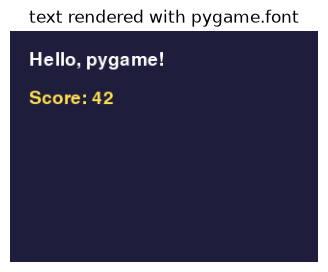

In [3]:
pygame.font.init()  # font rendering is its own little subsystem, needs its own init call

font = pygame.font.SysFont(None, 28)  # None = pygame's built-in default font, size 28
text_surface = font.render("Hello, pygame!", True, (255, 255, 255))  # (text, antialias, color)

screen.fill((30, 30, 60))
screen.blit(text_surface, (20, 20))  # blit = "draw this smaller surface onto the bigger one, at this (x, y) position"

# we can render the same text in a different color/style just as easily - useful for score displays, dialogue, menus, ...
score_surface = font.render("Score: 42", True, (255, 220, 80))
screen.blit(score_surface, (20, 60))

show_surface(screen, title="text rendered with pygame.font")

## the game loop
* almost every game, no matter the engine or language, is built around the same basic idea, called the **game loop**:
```
initialize everything
while the game is running:
    1. handle input/events (did the player press a key? close the window?)
    2. update the game state (move things, check collisions, update the score, ...)
    3. render/draw the current state to the screen
    4. wait just long enough to hit our target frame rate
quit / cleanup
```
* `pygame.time.Clock` helps with step 4 - `clock.tick(60)` waits just long enough so the loop runs at (at most) 60 times per second ("60 FPS", frames per second), and also tells us how much real time actually passed since the last call (useful for smooth movement regardless of the exact frame rate, often called "delta time")
* in THIS notebook we obviously can't run forever waiting for real keyboard input - instead we will run the loop for a FIXED number of frames, and simulate movement so you can see the idea working

In [4]:
clock = pygame.time.Clock()

# a little "ball" we will animate moving across the screen
ball_pos = [30.0, 120.0]   # use a list (not a tuple) so we can update its x/y in place
ball_velocity = [4.0, 0.0]  # moves 4 pixels per frame to the right, 0 vertically

captured_frames = []  # we will grab a few snapshots along the way to show the motion afterwards

TOTAL_FRAMES = 40
for frame_number in range(TOTAL_FRAMES):
    # step 1: handle events - in a real game with a real window this is where you'd check for QUIT/keyboard/mouse events
    pygame.event.pump()  # lets SDL process its internal event queue (good practice every frame, even if we dont read events yet)

    # step 2: update the game state
    ball_pos[0] += ball_velocity[0]
    if ball_pos[0] > 320:  # wrap back around to the left edge once it goes off the right side
        ball_pos[0] = 0

    # step 3: render
    screen.fill((30, 30, 60))
    pygame.draw.circle(screen, (240, 90, 90), (int(ball_pos[0]), int(ball_pos[1])), 15)

    if frame_number % 10 == 0:  # grab one snapshot every 10 frames, so we can look at the motion afterwards
        captured_frames.append((frame_number, pygame.surfarray.array3d(screen).swapaxes(0, 1).copy()))

    # step 4: (in a real game) clock.tick(60) would pace us to 60 fps and return the elapsed milliseconds
    delta_ms = clock.tick(60)

print(f"ran the game loop for {TOTAL_FRAMES} frames, captured {len(captured_frames)} snapshots along the way")
print("last clock.tick() reported", delta_ms, "milliseconds since the previous tick (this runs way faster than 60fps here, no real display to sync to)")

ran the game loop for 40 frames, captured 4 snapshots along the way
last clock.tick() reported 16 milliseconds since the previous tick (this runs way faster than 60fps here, no real display to sync to)


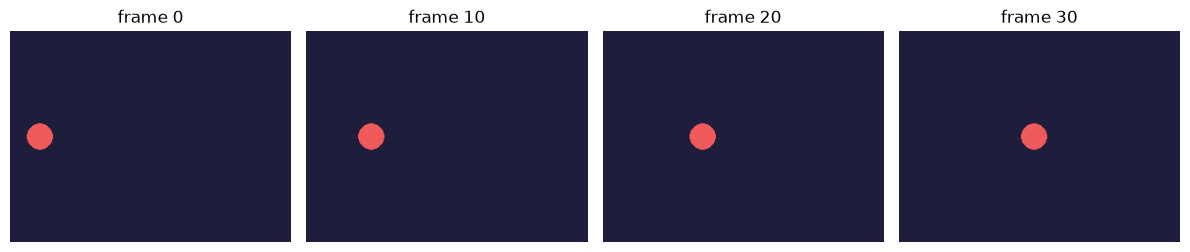

In [5]:
# lets look at the captured snapshots side by side, to actually SEE the ball moving across the screen over time
fig, axes = plt.subplots(1, len(captured_frames), figsize=(3 * len(captured_frames), 3))
for ax, (frame_number, frame_pixels) in zip(axes, captured_frames):
    ax.imshow(frame_pixels)
    ax.set_title(f"frame {frame_number}")
    ax.axis("off")
plt.tight_layout()
plt.show()

## handling input - simulating keyboard events
* in a real game, the standard way to check "is this key held down right now" is `pygame.key.get_pressed()` inside your loop, and "did this key just get pressed once" is checking `pygame.event.get()` for a `KEYDOWN` event
* since we have no real keyboard attached to this notebook, we SIMULATE input using `pygame.event.post(...)` - this puts a synthetic event into pygame's own event queue, exactly as if a real key had been pressed, so all the rest of our game code cant tell the difference
* this simulate-and-drive-forward technique is also genuinely useful for automated testing of real games!

key pressed: right
key released: right
player position after handling the simulated key presses: [155, 100]


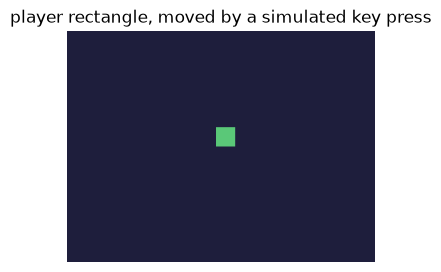

In [6]:
pygame.event.clear()  # discard any old/leftover events sitting in the queue from earlier cells, so we start clean

# lets simulate the player pressing the RIGHT arrow key, then releasing it
pygame.event.post(pygame.event.Event(pygame.KEYDOWN, key=pygame.K_RIGHT))
pygame.event.post(pygame.event.Event(pygame.KEYUP, key=pygame.K_RIGHT))

player_pos = [150, 100]
player_speed = 5

for event in pygame.event.get():  # this drains the queue - in a real game loop you call this once per frame
    if event.type == pygame.KEYDOWN:
        print("key pressed:", pygame.key.name(event.key))
        if event.key == pygame.K_RIGHT:
            player_pos[0] += player_speed
        elif event.key == pygame.K_LEFT:
            player_pos[0] -= player_speed
    elif event.type == pygame.KEYUP:
        print("key released:", pygame.key.name(event.key))

print("player position after handling the simulated key presses:", player_pos)

screen.fill((30, 30, 60))
pygame.draw.rect(screen, (90, 200, 120), (*player_pos, 20, 20))
show_surface(screen, title="player rectangle, moved by a simulated key press")

## collision detection with Rect
* `pygame.Rect(x, y, width, height)` is a small helper object pygame uses everywhere for exactly this - it has a ready-made `.colliderect(other_rect)` method that returns `True`/`False`
* this is by far the most common collision check in simple 2D games: "did this rectangle touch/overlap that rectangle" (a player and an enemy, a bullet and a wall, ...)

player vs far enemy collides?   False
player vs close enemy collides? True
is point (65, 60) inside player_rect? True


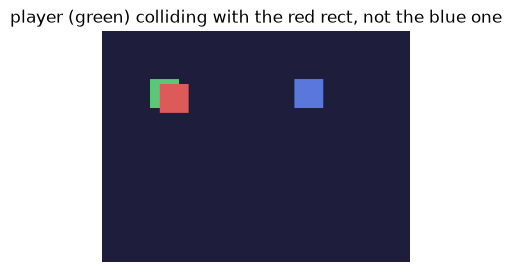

In [7]:
player_rect = pygame.Rect(50, 50, 30, 30)   # x, y, width, height
enemy_rect_far = pygame.Rect(200, 50, 30, 30)   # far away - should NOT collide
enemy_rect_close = pygame.Rect(60, 55, 30, 30)  # overlapping the player - SHOULD collide

print("player vs far enemy collides?  ", player_rect.colliderect(enemy_rect_far))
print("player vs close enemy collides?", player_rect.colliderect(enemy_rect_close))

# Rect also has handy helpers like .center, .top/.bottom/.left/.right, and moving/checking "is this point inside me"
print("is point (65, 60) inside player_rect?", player_rect.collidepoint((65, 60)))

screen.fill((30, 30, 60))
pygame.draw.rect(screen, (90, 200, 120), player_rect)
pygame.draw.rect(screen, (90, 120, 220), enemy_rect_far)
pygame.draw.rect(screen, (220, 90, 90), enemy_rect_close)  # this one visually overlaps the player rect
show_surface(screen, title="player (green) colliding with the red rect, not the blue one")

## a quick note on sound
* `pygame.mixer` handles sound effects and music - `pygame.mixer.init()`, `pygame.mixer.Sound("effect.wav")`, `sound.play()`
* our dummy audio driver lets `pygame.mixer.init()` succeed without errors (so this lesson doesn't crash), but obviously produces no actual audible sound here - and we have no sound FILE to load anyway, since this course stays dependency/asset-free
* on your own computer, with a real sound card and a real `.wav`/`.ogg` file, the exact same 3 lines of code would really play audio - nothing about the sound API itself changes, only the environment variable trick from the top of this lesson

In [8]:
pygame.mixer.init()  # succeeds thanks to the dummy audio driver, even though nothing will actually be audible
print("mixer initialized ok - frequency:", pygame.mixer.get_init())
# real usage would continue like this (not run here, we have no sound file):
#     jump_sound = pygame.mixer.Sound("jump.wav")
#     jump_sound.play()

mixer initialized ok - frequency: (44100, -16, 2)


## quick comparison to other languages/engines
* pygame's low-level, "draw everything yourself" style is closest to using raw **SDL** directly from C/C++, or **LÖVE** (Lua) - all three give you a blank canvas and basic building blocks, with no built-in scene editor or physics engine
* **Godot** (its own GDScript language, but also supports C#) and **Unity** (C#) are full game ENGINES with a visual editor, a scene graph, built-in physics, animation tools, and much more - pygame gives you none of that, you build your own game "engine" as you go, which is fantastic for learning what a game engine actually does under the hood
* JavaScript has **Phaser** (a pygame-like 2D framework, but runs directly in a web browser, no install needed for players) and **three.js** (for 3D, in the browser)
* pygame's game loop + draw + event-handling structure is genuinely the same shape you'll find in almost every 2D framework in any language - once you understand it here, reading Phaser/LÖVE/raw SDL code will feel very familiar

## Exercises
1. draw a small "scene" with at least 3 different shapes (using `pygame.draw`) and a line of text, then display it with `show_surface()`
2. animate a rectangle moving DIAGONALLY (both x and y changing every frame) for 30 frames, bouncing back (reverse its velocity) whenever it would go off any edge of a 320x240 screen, and show 4 snapshots of it
3. simulate pressing the LEFT, then UP, then RIGHT arrow keys (post all 3 as `KEYDOWN` events) and write the event-handling loop that moves a `player_pos` accordingly, printing the position after each key
4. create two `pygame.Rect` objects that do NOT currently collide, then move one of them (by changing its `.x`/`.y`) until `.colliderect()` becomes `True`, printing the result before and after

In [9]:
# TODO: solve exercise 1 here (a small scene: 3 shapes + text)


# TODO: solve exercise 2 here (a bouncing rectangle animation, 4 snapshots)


# TODO: solve exercise 3 here (simulate LEFT/UP/RIGHT key presses, move player_pos accordingly)


# TODO: solve exercise 4 here (two Rects, not colliding, then moved until they do)

### sample solutions
* try the exercises above yourself first, only look here if you are stuck or want to compare your approach

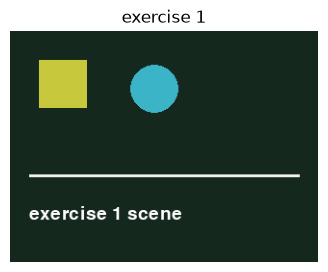

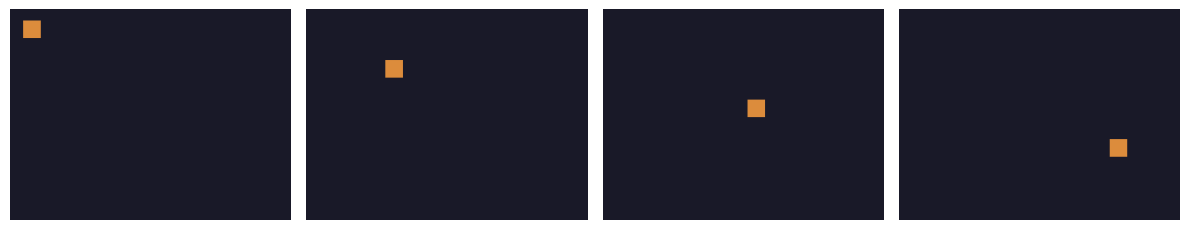

after left -> [95, 100]
after up -> [95, 95]
after right -> [100, 95]
collide before: False
collide after:  True (rect_a.x is now 90 )


In [10]:
# sample solution 1 - a small scene
screen.fill((20, 40, 30))
pygame.draw.rect(screen, (200, 200, 60), (30, 30, 50, 50))
pygame.draw.circle(screen, (60, 180, 200), (150, 60), 25)
pygame.draw.line(screen, (240, 240, 240), (20, 150), (300, 150), 3)
label = font.render("exercise 1 scene", True, (255, 255, 255))
screen.blit(label, (20, 180))
show_surface(screen, title="exercise 1")


# sample solution 2 - a bouncing diagonal rectangle
bounce_pos = [10.0, 10.0]
bounce_vel = [5.0, 3.0]
bounce_size = 20
snapshots = []

for frame_number in range(60):
    bounce_pos[0] += bounce_vel[0]
    bounce_pos[1] += bounce_vel[1]
    if bounce_pos[0] <= 0 or bounce_pos[0] + bounce_size >= 320:
        bounce_vel[0] *= -1  # reverse horizontal direction
    if bounce_pos[1] <= 0 or bounce_pos[1] + bounce_size >= 240:
        bounce_vel[1] *= -1  # reverse vertical direction

    screen.fill((25, 25, 40))
    pygame.draw.rect(screen, (220, 140, 60), (*[int(v) for v in bounce_pos], bounce_size, bounce_size))

    if frame_number % 15 == 0:
        snapshots.append(pygame.surfarray.array3d(screen).swapaxes(0, 1).copy())

fig, axes = plt.subplots(1, len(snapshots), figsize=(3 * len(snapshots), 3))
for ax, snap in zip(axes, snapshots):
    ax.imshow(snap)
    ax.axis("off")
plt.tight_layout()
plt.show()


# sample solution 3 - simulate LEFT, UP, RIGHT key presses
pygame.event.clear()
pygame.event.post(pygame.event.Event(pygame.KEYDOWN, key=pygame.K_LEFT))
pygame.event.post(pygame.event.Event(pygame.KEYDOWN, key=pygame.K_UP))
pygame.event.post(pygame.event.Event(pygame.KEYDOWN, key=pygame.K_RIGHT))

exercise_player_pos = [100, 100]
for event in pygame.event.get():
    if event.type == pygame.KEYDOWN:
        if event.key == pygame.K_LEFT:
            exercise_player_pos[0] -= 5
        elif event.key == pygame.K_RIGHT:
            exercise_player_pos[0] += 5
        elif event.key == pygame.K_UP:
            exercise_player_pos[1] -= 5
        print("after", pygame.key.name(event.key), "->", exercise_player_pos)


# sample solution 4 - two rects, moved until they collide
rect_a = pygame.Rect(0, 0, 20, 20)
rect_b = pygame.Rect(100, 0, 20, 20)
print("collide before:", rect_a.colliderect(rect_b))

while not rect_a.colliderect(rect_b):
    rect_a.x += 10  # step rect_a to the right, 10 pixels at a time, until it reaches rect_b

print("collide after: ", rect_a.colliderect(rect_b), "(rect_a.x is now", rect_a.x, ")")

* congratulation you finished this lesson

## what we learned
* what pygame is and why we set `SDL_VIDEODRIVER=dummy`/`SDL_AUDIODRIVER=dummy` specifically for THIS headless notebook environment (never needed on a normal computer)
* a reusable `show_surface()` helper: converting a pygame Surface to a numpy array and displaying it with matplotlib
* drawing primitives (`pygame.draw.rect/circle/line/polygon`) and rendering text with `pygame.font`
* the universal game loop shape: handle input -> update -> render -> tick the clock, and running it for a fixed number of frames to capture a "flipbook" of snapshots
* simulating keyboard input with `pygame.event.post()` and reading it back with `pygame.event.get()`, exactly like a real game loop would
* collision detection with `pygame.Rect.colliderect()`/`.collidepoint()`
* that `pygame.mixer` handles sound with the same 3-line pattern (`init()`, load a `Sound`, `.play()`) as on a real machine with real audio hardware